# Nombre: Carlos Iván Rueda P. / Proyecto del Componente de Planificación de Sistemas de Energía / 03-ago-2026

# Optimización de inversiones con CVaR

## Subsistema Paute–Austro–Guayaquil

El modelo emplea **Pyomo**, un flujo DC de potencia, escenarios estocásticos de estiaje y una función objetivo basada en CVaR.


## Instrucciones de uso

1. Ejecute las celdas en orden.
2. La primera celda instala únicamente las dependencias que falten.
3. Ejecute primero la **prueba rápida**.
4. Cuando la prueba termine correctamente, ejecute el estudio completo.

> El solver HiGHS se instala mediante el paquete `highspy`. Si existe una instalación válida de Gurobi, CBC o GLPK, el código también puede utilizarlos.


## 0. Preparación del entorno

In [1]:
# Instalación condicional de dependencias.
# Esta celda funciona en Jupyter Notebook, JupyterLab y Google Colab.
import importlib.util
import subprocess
import sys

DEPENDENCIAS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "pyomo": "pyomo",
    "highspy": "highspy",
}

for modulo, paquete in DEPENDENCIAS.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])

print("Dependencias verificadas.")


Dependencias verificadas.


In [2]:
from __future__ import annotations

import math
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from IPython.display import display
from pyomo.opt import TerminationCondition

PYOMO_AVAILABLE = True

# Permite mostrar los gráficos dentro del notebook.
%matplotlib inline


## 1. Parámetros del sistema ecuatoriano

Se definen barras, demanda, generadores, líneas, semillas y tamaños de muestra.

In [3]:
# =============================================================================
# 1. PARÁMETROS DEL SISTEMA ECUATORIANO (PAUTE - AUSTRO - GUAYAQUIL)
# =============================================================================

# Datos de la red (Tablas 1 y 2 de Tarea_06_CVaR_Pyomo_Gurobi_Ecuador_REV_A.pdf)
BUSES = ["Mazar", "Molino", "Sopladora", "Cuenca", "Loja", "Guayaquil"]

DEMAND_BASE = {
    "Mazar": 0.0,
    "Molino": 0.0,
    "Sopladora": 0.0,
    "Cuenca": 450.0,
    "Loja": 180.0,
    "Guayaquil": 1100.0
}

GENERATORS_DATA = {
    # Nombre: (Barra, Capacidad [MW], Costo Inversión, Tipo)
    "Mazar": ("Mazar", 170.0, 85.0, "Hidro-reservorio"),
    "Paute_Molino": ("Molino", 1100.0, 460.0, "Hidro-cascada"),
    "Sopladora": ("Sopladora", 487.0, 245.0, "Hidro-cascada"),
    "Delsitanisagua": ("Loja", 180.0, 90.0, "Hidro-pasada"),
    "Termo_Cuenca": ("Cuenca", 80.0, 40.0, "Térmica respaldo"),
    "Termo_Guayaquil": ("Guayaquil", 300.0, 150.0, "Térmica respaldo"),
    "Importacion_Peru": ("Loja", 150.0, 75.0, "Interconexión/reserva")
}

# Líneas de Transmisión (Cargabilidad máxima y reactancia académica)
# Formato: (Bus_Desde, Bus_Hasta, Capacidad_Flujo_MW, Reactancia_p.u.)
LINES_DATA = [
    ("Mazar", "Molino", 700.0, 0.1),
    ("Molino", "Sopladora", 700.0, 0.1),
    ("Molino", "Cuenca", 650.0, 0.1),
    ("Sopladora", "Cuenca", 500.0, 0.1),
    ("Sopladora", "Guayaquil", 650.0, 0.1),
    ("Cuenca", "Loja", 250.0, 0.1),
    ("Cuenca", "Guayaquil", 900.0, 0.1)
]

# Parámetros de la simulación estocástica
N_TRAIN = 300
N_VALIDATION = 1000
TRAIN_SEED = 20260720
VALIDATION_SEED = 20260721

OUTPUT_DIR = Path("resultados_ecuador_cvar")

## 2. Generación de escenarios de estiaje severo

La función genera pérdidas de capacidad y multiplicadores de demanda.

In [4]:
# =============================================================================
# 2. GENERADOR DE ESCENARIOS DE ESTIAJE SEVERO
# =============================================================================

def generate_drought_scenarios(n_scenarios: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera escenarios de reducción de capacidad por estiaje severo en Ecuador.
    Las centrales hidroeléctricas sufren reducciones severas en su caudal de diseño.
    Las unidades térmicas y la interconexión con Perú tienen alta confiabilidad.
    """
    rng = np.random.default_rng(seed)
    gen_names = list(GENERATORS_DATA.keys())
    n_gen = len(gen_names)

    # Matriz para guardar alfa_e,j (fracción de capacidad perdida, de 0 a 1)
    alpha = np.zeros((n_scenarios, n_gen))

    # Multiplicador de aumento de demanda por contingencia (calor, fallas, etc.)
    demand_multiplier = np.ones(n_scenarios)

    # Generamos los escenarios simulando la severidad del estiaje
    for e in range(n_scenarios):
        # Severidad global del estiaje: 40% operación normal, 40% moderada, 20% estiaje severo/extremo
        draw = rng.random()
        if draw < 0.40:
            severity = rng.uniform(0.05, 0.20)  # Normal
        elif draw < 0.80:
            severity = rng.uniform(0.20, 0.60)  # Moderado
        else:
            severity = rng.uniform(0.60, 0.95)  # Estiaje severo extremo

        # Aumento leve de la demanda durante eventos críticos (por ej. uso de ventilación o ineficiencias)
        demand_multiplier[e] = 1.0 + 0.05 * severity

        for j, (name, info) in enumerate(GENERATORS_DATA.items()):
            tech_type = info[3]
            if "Hidro" in tech_type:
                # Las hidroeléctricas son muy vulnerables al estiaje
                vulnerability = 0.85 if "cascada" in tech_type else 0.70
                alpha[e, j] = severity * vulnerability + rng.normal(0.0, 0.03)
            else:
                # Las centrales térmicas y la interconexión tienen poca vulnerabilidad al estiaje
                alpha[e, j] = rng.uniform(0.0, 0.12)

    alpha = np.clip(alpha, 0.0, 1.0)
    return alpha, demand_multiplier

## 3. Modelo de optimización de dos etapas con CVaR

In [5]:
# =============================================================================
# 3. CONSTRUCCIÓN DEL MODELO EN PYOMO
# =============================================================================

def build_pyomo_model(
    alpha: np.ndarray,
    demand_multiplier: np.ndarray,
    epsilon: float,
    budget: float
) -> pyo.ConcreteModel:
    """
    Construye el modelo matemático MILP de dos etapas adverso al riesgo con CVaR
    para el subsistema Paute-Austro-Guayaquil.
    """
    n_scenarios, n_gen = alpha.shape
    n_buses = len(BUSES)
    n_lines = len(LINES_DATA)

    gen_names = list(GENERATORS_DATA.keys())

    model = pyo.ConcreteModel(name=f"Ecuador_CVaR_eps_{epsilon}")

    # Conjuntos
    model.E = pyo.RangeSet(0, n_scenarios - 1)
    model.B = pyo.Set(initialize=BUSES)
    model.G = pyo.Set(initialize=gen_names)
    model.L = pyo.RangeSet(0, n_lines - 1)

    # Variables de 1ra etapa (Decisión binaria de inversión para proteger cada recurso)
    model.x = pyo.Var(model.G, domain=pyo.Binary)

    # Variables auxiliares para el cálculo de riesgo CVaR (linealización)
    model.beta = pyo.Var(domain=pyo.Reals)
    model.t = pyo.Var(model.E, domain=pyo.NonNegativeReals)

    # Variables de 2da etapa (operación del sistema por cada escenario e)
    model.pg = pyo.Var(model.E, model.G, domain=pyo.NonNegativeReals)
    model.ls = pyo.Var(model.E, model.B, domain=pyo.NonNegativeReals)
    model.theta = pyo.Var(model.E, model.B, domain=pyo.Reals, bounds=(-math.pi, math.pi))
    model.flow = pyo.Var(model.E, model.L, domain=pyo.Reals)

    # --- Restricciones de 1ra etapa ---

    # Restricción de Presupuesto Equivalente
    def budget_rule(m):
        return sum(GENERATORS_DATA[g][2] * m.x[g] for g in m.G) <= budget
    model.budget_constraint = pyo.Constraint(rule=budget_rule)

    # --- Restricciones de 2da etapa por escenario ---

    # Referencia angular (Cuenca es la barra slack de referencia)
    def slack_rule(m, e):
        return m.theta[e, "Cuenca"] == 0.0
    model.slack_angle = pyo.Constraint(model.E, rule=slack_rule)

    # Capacidad máxima disponible del generador ajustada por inversión y estiaje
    def generation_capacity_rule(m, e, g):
        g_idx = gen_names.index(g)
        pmax = GENERATORS_DATA[g][1]
        # Si x[g] = 1, la capacidad es pmax. Si x[g] = 0, se reduce por (1 - alpha_eg)
        capacidad_disponible = pmax * (1.0 - (1.0 - m.x[g]) * float(alpha[e, g_idx]))
        return m.pg[e, g] <= capacidad_disponible
    model.generation_capacity = pyo.Constraint(model.E, model.G, rule=generation_capacity_rule)

    # Límite del deslastre de carga por barra
    def load_shed_limit_rule(m, e, b):
        demanda_escenario = DEMAND_BASE[b] * float(demand_multiplier[e])
        return m.ls[e, b] <= demanda_escenario
    model.load_shed_limit = pyo.Constraint(model.E, model.B, rule=load_shed_limit_rule)

    # Definición de flujos de potencia DC de la línea
    def line_flow_rule(m, e, l):
        u, v, _, reactancia = LINES_DATA[l]
        susceptancia = 1.0 / reactancia
        # Ley de Ohm para flujo DC: F = B * (theta_u - theta_v)
        return m.flow[e, l] == susceptancia * (m.theta[e, u] - m.theta[e, v])
    model.line_flow = pyo.Constraint(model.E, model.L, rule=line_flow_rule)

    # Límites de transmisión de las líneas
    def line_thermal_upper_rule(m, e, l):
        capacidad_limite = LINES_DATA[l][2]
        return m.flow[e, l] <= capacidad_limite
    model.line_thermal_upper = pyo.Constraint(model.E, model.L, rule=line_thermal_upper_rule)

    def line_thermal_lower_rule(m, e, l):
        capacidad_limite = LINES_DATA[l][2]
        return m.flow[e, l] >= -capacidad_limite
    model.line_thermal_lower = pyo.Constraint(model.E, model.L, rule=line_thermal_lower_rule)

    # Balance nodal de potencia (1ra ley de Kirchhoff para corriente alterna aproximada DC)
    def nodal_balance_rule(m, e, b):
        # Generadores conectados a la barra b
        generacion_barra = sum(m.pg[e, g] for g in m.G if GENERATORS_DATA[g][0] == b)

        # Flujo neto saliente de la barra b
        flujo_neto = 0.0
        for l, (u, v, _, _) in enumerate(LINES_DATA):
            if u == b:
                flujo_neto += m.flow[e, l]  # Sale de b
            elif v == b:
                flujo_neto -= m.flow[e, l]  # Entra a b

        demanda_escenario = DEMAND_BASE[b] * float(demand_multiplier[e])

        # Generación + Deslastre - Demanda = Flujo Neto Saliente
        return generacion_barra + m.ls[e, b] - demanda_escenario == flujo_neto
    model.nodal_balance = pyo.Constraint(model.E, model.B, rule=nodal_balance_rule)

    # --- Formulación de Riesgo CVaR ---

    # Expresión para la pérdida total en cada escenario (Deslastre total)
    def loss_rule(m, e):
        return sum(m.ls[e, b] for b in m.B)
    model.loss = pyo.Expression(model.E, rule=loss_rule)

    # Restricción t_e >= pérdida_e - beta
    def cvar_excess_rule(m, e):
        return m.t[e] >= m.loss[e] - m.beta
    model.cvar_excess = pyo.Constraint(model.E, rule=cvar_excess_rule)

    # Función Objetivo: Minimizar CVaR_epsilon
    prob = 1.0 / float(n_scenarios)
    model.objective = pyo.Objective(
        expr=model.beta + (1.0 / float(epsilon)) * prob * sum(model.t[e] for e in model.E),
        sense=pyo.minimize
    )

    return model

## 4. Modelo de validación fuera de muestra

Las decisiones binarias de inversión se fijan y se evalúan en nuevos escenarios.

In [6]:
# =============================================================================
# 4. MODELO DE VALIDACIÓN FUERA DE MUESTRA (DECISIONES FIJAS)
# =============================================================================

def build_validation_model(
    alpha: np.ndarray,
    demand_multiplier: np.ndarray,
    x_fixed: np.ndarray
) -> pyo.ConcreteModel:
    """
    Evalúa el deslastre de carga en escenarios fuera de muestra fijando
    las decisiones de inversión obtenidas en la primera etapa.
    """
    n_scenarios, n_gen = alpha.shape
    n_buses = len(BUSES)
    n_lines = len(LINES_DATA)
    gen_names = list(GENERATORS_DATA.keys())

    model = pyo.ConcreteModel(name="Ecuador_Validation")

    model.E = pyo.RangeSet(0, n_scenarios - 1)
    model.B = pyo.Set(initialize=BUSES)
    model.G = pyo.Set(initialize=gen_names)
    model.L = pyo.RangeSet(0, n_lines - 1)

    model.pg = pyo.Var(model.E, model.G, domain=pyo.NonNegativeReals)
    model.ls = pyo.Var(model.E, model.B, domain=pyo.NonNegativeReals)
    model.theta = pyo.Var(model.E, model.B, domain=pyo.Reals, bounds=(-math.pi, math.pi))
    model.flow = pyo.Var(model.E, model.L, domain=pyo.Reals)

    model.slack_angle = pyo.Constraint(model.E, rule=lambda m, e: m.theta[e, "Cuenca"] == 0.0)

    def generation_capacity_rule(m, e, g):
        g_idx = gen_names.index(g)
        pmax = GENERATORS_DATA[g][1]
        capacidad_disponible = pmax * (1.0 - (1.0 - float(x_fixed[g_idx])) * float(alpha[e, g_idx]))
        return m.pg[e, g] <= capacidad_disponible
    model.generation_capacity = pyo.Constraint(model.E, model.G, rule=generation_capacity_rule)

    def load_shed_limit_rule(m, e, b):
        demanda_escenario = DEMAND_BASE[b] * float(demand_multiplier[e])
        return m.ls[e, b] <= demanda_escenario
    model.load_shed_limit = pyo.Constraint(model.E, model.B, rule=load_shed_limit_rule)

    def line_flow_rule(m, e, l):
        u, v, _, reactancia = LINES_DATA[l]
        susceptancia = 1.0 / reactancia
        return m.flow[e, l] == susceptancia * (m.theta[e, u] - m.theta[e, v])
    model.line_flow = pyo.Constraint(model.E, model.L, rule=line_flow_rule)

    model.line_thermal_upper = pyo.Constraint(model.E, model.L, rule=lambda m, e, l: m.flow[e, l] <= LINES_DATA[l][2])
    model.line_thermal_lower = pyo.Constraint(model.E, model.L, rule=lambda m, e, l: m.flow[e, l] >= -LINES_DATA[l][2])

    def nodal_balance_rule(m, e, b):
        generacion_barra = sum(m.pg[e, g] for g in m.G if GENERATORS_DATA[g][0] == b)
        flujo_neto = sum(m.flow[e, l] for l, (u, v, _, _) in enumerate(LINES_DATA) if u == b) - \
                     sum(m.flow[e, l] for l, (u, v, _, _) in enumerate(LINES_DATA) if v == b)
        demanda_escenario = DEMAND_BASE[b] * float(demand_multiplier[e])
        return generacion_barra + m.ls[e, b] - demanda_escenario == flujo_neto
    model.nodal_balance = pyo.Constraint(model.E, model.B, rule=nodal_balance_rule)

    def loss_rule(m, e):
        return sum(m.ls[e, b] for b in m.B)
    model.loss = pyo.Expression(model.E, rule=loss_rule)

    model.objective = pyo.Objective(
        expr=sum(model.ls[e, b] for e in model.E for b in model.B),
        sense=pyo.minimize
    )

    return model

## 5. Resolución y métricas de riesgo

In [7]:
# =============================================================================
# 5. RESOLUCIÓN DE OPTIMIZACIÓN Y MÉTRICAS DE RIESGO
# =============================================================================

def solve_model(model: pyo.ConcreteModel) -> Tuple[bool, str]:
    """Intenta resolver el modelo Pyomo usando solvers comunes."""
    solvers = ["highs", "gurobi", "cbc", "glpk"]
    for s_name in solvers:
        try:
            solver = pyo.SolverFactory(s_name)
            if solver.available(exception_flag=False):
                results = solver.solve(model, tee=False)
                if results.solver.termination_condition in [TerminationCondition.optimal, TerminationCondition.feasible]:
                    return True, s_name
        except Exception:
            continue
    return False, "Ninguno"

def calculate_empirical_cvar(losses: np.ndarray, epsilon: float) -> float:
    """Calcula el CVaR empírico ex-post sobre el vector de pérdidas."""
    sorted_losses = np.sort(losses)[::-1]
    n_samples = sorted_losses.size
    tail_size = epsilon * n_samples
    full_samples = int(math.floor(tail_size))
    fractional = tail_size - full_samples

    total_loss = sorted_losses[:full_samples].sum() if full_samples > 0 else 0.0
    if fractional > 1e-9 and full_samples < n_samples:
        total_loss += fractional * sorted_losses[full_samples]
    return float(total_loss / tail_size)

## 6. Función de ejecución


In [8]:
def run_study(
    presupuestos=None,
    epsilons=None,
    n_train=N_TRAIN,
    n_validation=N_VALIDATION,
    train_seed=TRAIN_SEED,
    validation_seed=VALIDATION_SEED,
):
    """Ejecuta el estudio completo y devuelve los resultados de validación."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if presupuestos is None:
        presupuestos = [0.0, 300.0, 460.0]
    if epsilons is None:
        epsilons = [1.0, 0.10, 0.05]

    print("--- Simulador Estocástico CVaR para Paute-Austro-Guayaquil ---")
    print(f"Buses del sistema: {BUSES}")
    print(f"Demanda total nominal: {sum(DEMAND_BASE.values())} MW")

    print(
        f"\n--- Generando {n_train} escenarios de entrenamiento "
        f"y {n_validation} de validación ---"
    )
    alpha_train, dem_train = generate_drought_scenarios(n_train, train_seed)
    alpha_val, dem_val = generate_drought_scenarios(n_validation, validation_seed)

    results_list = []
    validation_losses_dict = {}
    gen_names = list(GENERATORS_DATA.keys())

    print("\n--- Ejecutando optimización en Pyomo ---")

    for presupuesto in presupuestos:
        for epsilon in epsilons:
            print(
                f"Optimizando para Presupuesto = {presupuesto} | "
                f"Epsilon = {epsilon}..."
            )

            model = build_pyomo_model(
                alpha=alpha_train,
                demand_multiplier=dem_train,
                epsilon=epsilon,
                budget=presupuesto,
            )
            success, solver_used = solve_model(model)

            if not success:
                print(
                    "  [ERROR] No se pudo resolver el modelo de entrenamiento "
                    f"para Presupuesto={presupuesto}, Epsilon={epsilon}."
                )
                continue

            x_sol = np.array([pyo.value(model.x[g]) for g in model.G])
            inversiones_elegidas = [
                gen_names[i]
                for i, valor in enumerate(x_sol)
                if valor > 0.5
            ]

            val_model = build_validation_model(
                alpha=alpha_val,
                demand_multiplier=dem_val,
                x_fixed=x_sol,
            )
            validation_success, validation_solver = solve_model(val_model)

            if not validation_success:
                print(
                    "  [ERROR] No se pudo resolver el modelo de validación "
                    f"para Presupuesto={presupuesto}, Epsilon={epsilon}."
                )
                continue

            losses = np.array(
                [pyo.value(val_model.loss[e]) for e in val_model.E],
                dtype=float,
            )

            avg_loss = float(losses.mean())
            cvar_5 = calculate_empirical_cvar(losses, 0.05)
            max_loss = float(losses.max())

            results_list.append(
                {
                    "Presupuesto": presupuesto,
                    "Epsilon": epsilon,
                    "Inversiones": (
                        " + ".join(inversiones_elegidas)
                        if inversiones_elegidas
                        else "Ninguna"
                    ),
                    "Solver_entrenamiento": solver_used,
                    "Solver_validación": validation_solver,
                    "Media_deslastre_MW": avg_loss,
                    "CVaR_5pct_MW": cvar_5,
                    "Máximo_deslastre_MW": max_loss,
                }
            )

            if np.isclose(epsilon, 0.05):
                validation_losses_dict[presupuesto] = losses

    if not results_list:
        print("\nNo se obtuvieron resultados. Verifique la disponibilidad del solver.")
        return pd.DataFrame(), validation_losses_dict

    df_results = pd.DataFrame(results_list)

    print("\nTabla de resultados de validación:")
    display(
        df_results.style.format(
            {
                "Presupuesto": "{:.1f}",
                "Epsilon": "{:.3f}",
                "Media_deslastre_MW": "{:.2f}",
                "CVaR_5pct_MW": "{:.2f}",
                "Máximo_deslastre_MW": "{:.2f}",
            }
        )
    )

    csv_path = OUTPUT_DIR / "resultados_validacion_cvar.csv"
    df_results.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"Resultados guardados en: {csv_path.resolve()}")

    if validation_losses_dict:
        plt.figure(figsize=(10, 6))
        for presupuesto, losses in validation_losses_dict.items():
            plt.hist(
                losses,
                bins=40,
                alpha=0.5,
                label=f"Presupuesto = {presupuesto} (ε = 0.05)",
            )

        plt.title("Distribución de deslastre de carga en validación")
        plt.xlabel("Deslastre de carga total [MW]")
        plt.ylabel("Frecuencia de escenarios")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()

        fig_path = OUTPUT_DIR / "ecuador_drought_resilience.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Gráfico guardado en: {fig_path.resolve()}")
        plt.show()

    return df_results, validation_losses_dict


## 7. Prueba rápida

Ejecute esta celda para verificar el entorno antes del estudio completo.

--- Simulador Estocástico CVaR para Paute-Austro-Guayaquil ---
Buses del sistema: ['Mazar', 'Molino', 'Sopladora', 'Cuenca', 'Loja', 'Guayaquil']
Demanda total nominal: 1730.0 MW

--- Generando 20 escenarios de entrenamiento y 50 de validación ---

--- Ejecutando optimización en Pyomo ---
Optimizando para Presupuesto = 300.0 | Epsilon = 0.05...

Tabla de resultados de validación:


,Presupuesto,Epsilon,Inversiones,Solver_entrenamiento,Solver_validación,Media_deslastre_MW,CVaR_5pct_MW,Máximo_deslastre_MW
0,300.0,0.050,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil,highs,highs,1041.98,1086.66,1090.26


Resultados guardados en: /content/resultados_ecuador_cvar/resultados_validacion_cvar.csv
Gráfico guardado en: /content/resultados_ecuador_cvar/ecuador_drought_resilience.png


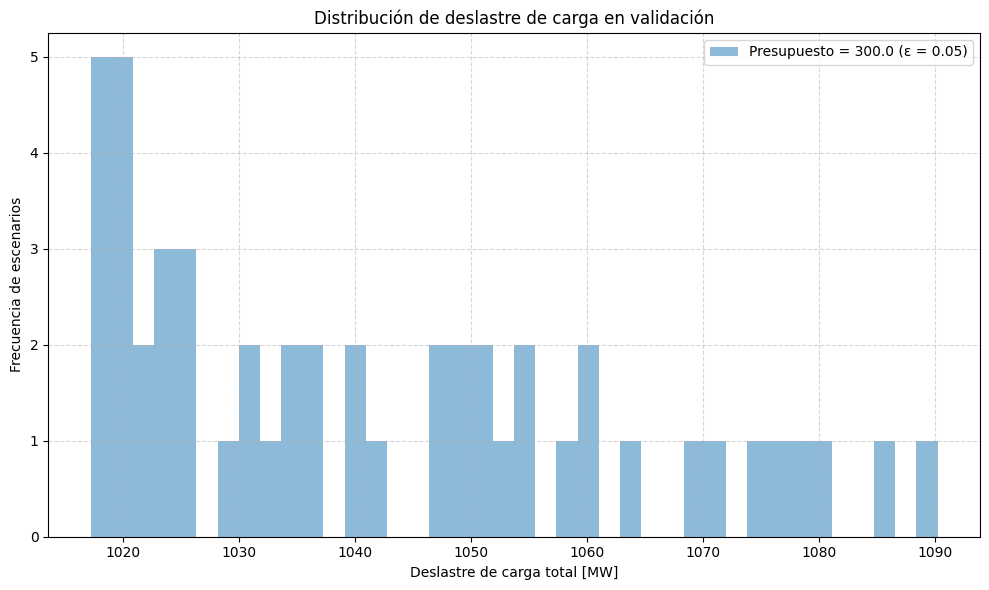

In [9]:
# Prueba rápida opcional para comprobar que el modelo y el solver funcionan.
# Emplea pocos escenarios y un único caso para reducir el tiempo de ejecución.
df_prueba, perdidas_prueba = run_study(
    presupuestos=[300.0],
    epsilons=[0.05],
    n_train=20,
    n_validation=50,
)


## 8. Ejecución completa

Esta celda reproduce los 300 escenarios de entrenamiento, 1000 escenarios de validación, tres presupuestos y tres valores de ε.

--- Simulador Estocástico CVaR para Paute-Austro-Guayaquil ---
Buses del sistema: ['Mazar', 'Molino', 'Sopladora', 'Cuenca', 'Loja', 'Guayaquil']
Demanda total nominal: 1730.0 MW

--- Generando 300 escenarios de entrenamiento y 1000 de validación ---

--- Ejecutando optimización en Pyomo ---
Optimizando para Presupuesto = 0.0 | Epsilon = 1.0...
Optimizando para Presupuesto = 0.0 | Epsilon = 0.1...
Optimizando para Presupuesto = 0.0 | Epsilon = 0.05...
Optimizando para Presupuesto = 300.0 | Epsilon = 1.0...
Optimizando para Presupuesto = 300.0 | Epsilon = 0.1...
Optimizando para Presupuesto = 300.0 | Epsilon = 0.05...
Optimizando para Presupuesto = 460.0 | Epsilon = 1.0...
Optimizando para Presupuesto = 460.0 | Epsilon = 0.1...
Optimizando para Presupuesto = 460.0 | Epsilon = 0.05...

Tabla de resultados de validación:


,Presupuesto,Epsilon,Inversiones,Solver_entrenamiento,Solver_validación,Media_deslastre_MW,CVaR_5pct_MW,Máximo_deslastre_MW
0,0.0,1.000,Ninguna,highs,highs,1064.49,1123.66,1150.54
1,0.0,0.100,Ninguna,highs,highs,1064.49,1123.66,1150.54
2,0.0,0.050,Ninguna,highs,highs,1064.49,1123.66,1150.54
3,300.0,1.000,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil,highs,highs,1041.15,1082.57,1098.49
4,300.0,0.100,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil,highs,highs,1041.15,1082.57,1098.49
5,300.0,0.050,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil,highs,highs,1041.15,1082.57,1098.49
6,460.0,1.000,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil + Importacion_Peru,highs,highs,1041.15,1082.57,1098.49
7,460.0,0.100,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil + Importacion_Peru,highs,highs,1041.15,1082.57,1098.49
8,460.0,0.050,Delsitanisagua + Termo_Cuenca + Termo_Guayaquil + Importacion_Peru,highs,highs,1041.15,1082.57,1098.49


Resultados guardados en: /content/resultados_ecuador_cvar/resultados_validacion_cvar.csv
Gráfico guardado en: /content/resultados_ecuador_cvar/ecuador_drought_resilience.png


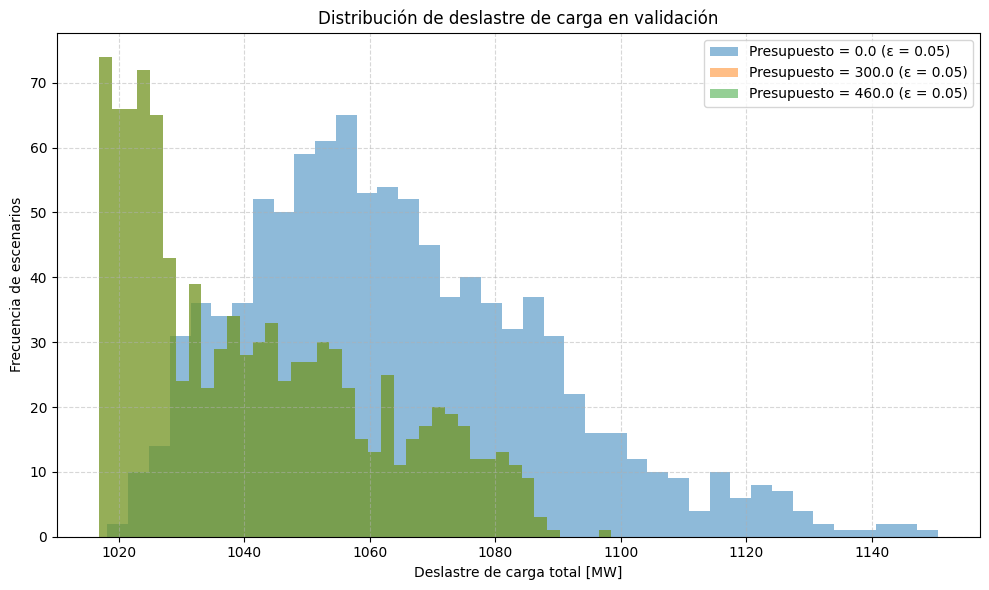

In [10]:
# Ejecución completa del estudio original.
# Puede requerir varios minutos, según el equipo y el solver disponible.
df_resultados, perdidas_validacion = run_study()
